# Assignment 2: ARMA Processes and Seasonal Processes

**Course:** Time Series Analysis  


This notebook contains a full Python solution for Assignment 2.



## Setup

The next cell imports the needed packages and defines a few helper functions.
These helpers are reused across the seasonal simulation questions.


In [1]:
# Basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Time-series tools
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Used to show the figure in Section 3
from IPython.display import Image, display

# Keep plots simple and readable
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False


def build_lag_polynomial(nonseasonal=None, seasonal=None, season_length=12, kind="ar"):
    # Start with the constant term
    polynomial = np.array([1.0])

    # Add non-seasonal lags
    if nonseasonal:
        current = np.zeros(max(nonseasonal.keys()) + 1)
        current[0] = 1.0
        for lag, coefficient in nonseasonal.items():
            current[lag] = -coefficient if kind == "ar" else coefficient
        polynomial = np.convolve(polynomial, current)

    # Add seasonal lags
    if seasonal:
        current = np.zeros(max(seasonal.keys()) * season_length + 1)
        current[0] = 1.0
        for seasonal_lag, coefficient in seasonal.items():
            current[seasonal_lag * season_length] = -coefficient if kind == "ar" else coefficient
        polynomial = np.convolve(polynomial, current)

    return polynomial


def simulate_multiplicative_seasonal_arma(
    ar_coefs=None,
    ma_coefs=None,
    sar_coefs=None,
    sma_coefs=None,
    season_length=12,
    n=300,
    burnin=500,
    seed=123,
):
    # Fix the seed so results are reproducible
    np.random.seed(seed)

    # Store coefficients by lag
    ar_terms = {i + 1: value for i, value in enumerate(ar_coefs or [])}
    ma_terms = {i + 1: value for i, value in enumerate(ma_coefs or [])}
    sar_terms = {i + 1: value for i, value in enumerate(sar_coefs or [])}
    sma_terms = {i + 1: value for i, value in enumerate(sma_coefs or [])}

    # Build full lag polynomials
    ar_polynomial = build_lag_polynomial(
        nonseasonal=ar_terms,
        seasonal=sar_terms,
        season_length=season_length,
        kind="ar",
    )
    ma_polynomial = build_lag_polynomial(
        nonseasonal=ma_terms,
        seasonal=sma_terms,
        season_length=season_length,
        kind="ma",
    )

    # Tiny safety note: statsmodels uses full AR and MA polynomials
    simulated = arma_generate_sample(
        ar=ar_polynomial,
        ma=ma_polynomial,
        nsample=n,
        burnin=burnin,
    )

    return simulated, ar_polynomial, ma_polynomial


def plot_series_acf_pacf(series, title, lags=50):
    # One row: series, ACF, PACF
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(series, color="black", linewidth=1.0)
    axes[0].set_title(f"{title}\nTime series")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Value")

    plot_acf(series, lags=lags, ax=axes[1], zero=False)
    axes[1].set_title("ACF")

    plot_pacf(series, lags=lags, ax=axes[2], zero=False, method="ywm")
    axes[2].set_title("PACF")

    plt.tight_layout()
    plt.show()

# Exam summary (recipe):
# Build the lag polynomials carefully, simulate the model, then read the
# time series, ACF, and PACF together.


# 1. Stability of the AR(2) process

We study

$$
X_t + \phi_1 X_{t-1} + \phi_2 X_{t-2} = \varepsilon_t,
\qquad \varepsilon_t \sim WN(0,1),
$$

with

$$
\phi_1 = -0.7, \qquad \phi_2 = -0.2.
$$

The next cell checks stationarity, computes the theoretical ACF, and plots it.


Characteristic equation roots:
  Root 1: -4.589454   |root| = 4.589454
  Root 2: 1.089454   |root| = 1.089454

Stationary? True

Invertibility comment:
  Invertibility is mainly a property of MA models.
  For this pure AR(2) model, stationarity is the relevant condition.


,lag,rho(k)
0,0,1.000000
1,1,0.875000
2,2,0.812500
3,3,0.743750
4,4,0.683125
5,5,0.626937
6,6,0.575481
7,7,0.528224
8,8,0.484853
9,9,0.445042


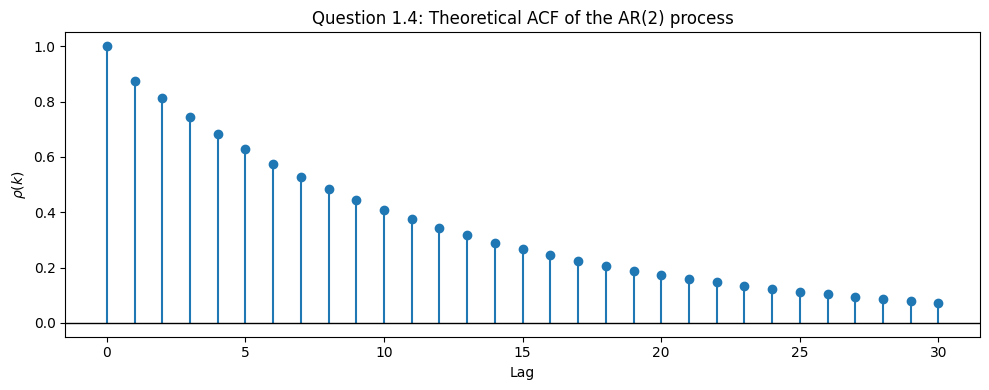

In [2]:
# Given coefficients
phi1 = -0.7
phi2 = -0.2

# Characteristic equation:
# 1 + phi_1 z + phi_2 z^2 = 0
characteristic_coefficients = [phi2, phi1, 1.0]

# Roots and their moduli
roots = np.roots(characteristic_coefficients)
root_moduli = np.abs(roots)

# Stationarity check: all roots must be outside the unit circle
is_stationary = np.all(root_moduli > 1)

print("Characteristic equation roots:")
for i, root in enumerate(roots, start=1):
    print(f"  Root {i}: {root:.6f}   |root| = {abs(root):.6f}")

print(f"\nStationary? {is_stationary}")

print("\nInvertibility comment:")
print("  For a pure AR model, stationarity is the key condition here.")

# Theoretical ACF by recursion
max_lag = 30
rho = np.zeros(max_lag + 1)
rho[0] = 1.0
rho[1] = -phi1 / (1.0 + phi2)

for k in range(2, max_lag + 1):
    rho[k] = -phi1 * rho[k - 1] - phi2 * rho[k - 2]

acf_table = pd.DataFrame({
    "lag": np.arange(0, 11),
    "rho(k)": np.round(rho[:11], 6),
})

display(acf_table)

plt.figure(figsize=(10, 4))
plt.stem(np.arange(max_lag + 1), rho, basefmt=" ")
plt.axhline(0, color="black", linewidth=1)
plt.title("Question 1.4: Theoretical ACF of the AR(2) process")
plt.xlabel("Lag")
plt.ylabel(r"$\rho(k)$")
plt.tight_layout()
plt.show()

# Exam summary (recipe):
# Compute the roots, check stationarity, then build rho(k) from rho(0), rho(1),
# and the AR(2) recursion.


## Short comment on Section 1

The roots lie outside the unit circle, so the AR(2) process is stationary.

For this pure AR model, stationarity is the main condition to discuss.  
The theoretical ACF starts at

$$
\rho(0)=1, \qquad \rho(1)=\frac{-\phi_1}{1+\phi_2},
$$

and then follows the AR(2) recursion.
The plot shows a smooth positive decay, which matches the given coefficients.


# 2. Simulating seasonal processes

Here all models have $d=D=0$, so we simulate them directly.

For each question, we show:
- the simulated series,
- the ACF,
- the PACF,
- and a short interpretation.


## 2.1 Model $(1,0,0) \times (0,0,0)_{12}$ with $\phi_1 = 0.6$

This is just a non-seasonal AR(1) model:

$$
Y_t = 0.6Y_{t-1} + \varepsilon_t.
$$

Expected pattern:
- no seasonality,
- slowly decaying ACF,
- one clear PACF spike at lag 1.


AR polynomial coefficients: [ 1.  -0.6]
MA polynomial coefficients: [1.]


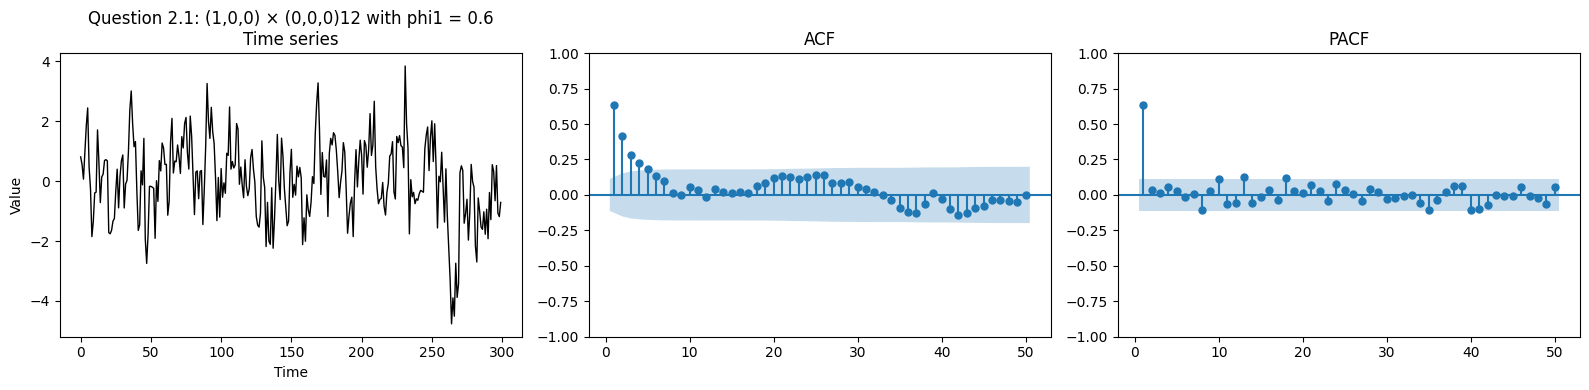

In [3]:
# Question 2.1
series_21, ar_poly_21, ma_poly_21 = simulate_multiplicative_seasonal_arma(
    ar_coefs=[0.6],
    ma_coefs=[],
    sar_coefs=[],
    sma_coefs=[],
    season_length=12,
    n=300,
    seed=123,
)

print("AR polynomial coefficients:", ar_poly_21)
print("MA polynomial coefficients:", ma_poly_21)

plot_series_acf_pacf(series_21, "Question 2.1: (1,0,0) × (0,0,0)12 with phi1 = 0.6")

# Exam summary (recipe):
# For AR(1), expect persistence in the series, a slowly decaying ACF,
# and a PACF dominated by lag 1.


### Comment on 2.1

This looks like a standard AR(1) process.
The series has short memory, the ACF tails off, and the PACF is mainly driven by lag 1.
That is the usual AR(1) signature.


## 2.2 Model $(0,0,0) \times (1,0,0)_{12}$ with $\Phi_1 = -0.9$

This is a seasonal AR(1) model:

$$
Y_t = -0.9Y_{t-12} + \varepsilon_t.
$$

Expected pattern:
- clear seasonal dependence,
- strongest behavior at lags $12,24,36,\dots$,
- alternating seasonal signs because the coefficient is negative.


AR polynomial coefficients: [1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.9]
MA polynomial coefficients: [1.]


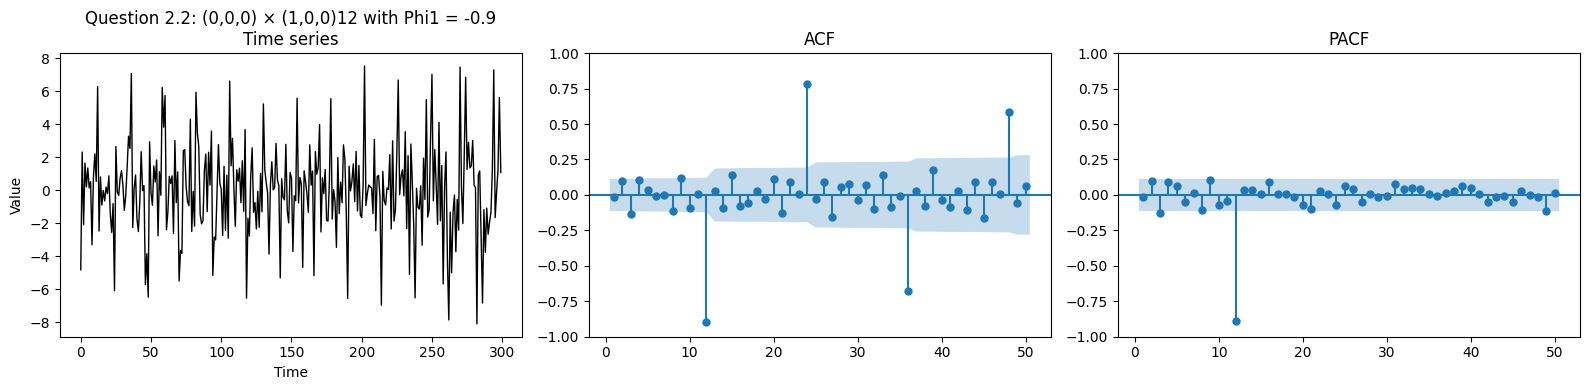

In [4]:
# Question 2.2
series_22, ar_poly_22, ma_poly_22 = simulate_multiplicative_seasonal_arma(
    ar_coefs=[],
    ma_coefs=[],
    sar_coefs=[-0.9],
    sma_coefs=[],
    season_length=12,
    n=300,
    seed=123,
)

print("AR polynomial coefficients:", ar_poly_22)
print("MA polynomial coefficients:", ma_poly_22)

plot_series_acf_pacf(series_22, "Question 2.2: (0,0,0) × (1,0,0)12 with Phi1 = -0.9")

# Exam summary (recipe):
# For a seasonal AR term, focus on lags 12, 24, 36, ...
# A negative seasonal coefficient can flip the seasonal signs.


### Comment on 2.2

The seasonal effect is clear.
The ACF is most informative at multiples of 12, and the PACF shows a strong seasonal spike near lag 12.
That matches a seasonal AR term.


## 2.3 Model $(1,0,0) \times (0,0,1)_{12}$ with $\phi_1 = 0.9$ and $\Theta_1 = -0.7$

This model combines:
- a strong non-seasonal AR(1),
- and a seasonal MA(1).

Expected pattern:
- slow ACF decay from the AR part,
- plus a seasonal feature around lag 12.


AR polynomial coefficients: [ 1.  -0.9]
MA polynomial coefficients: [ 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  -0.7]


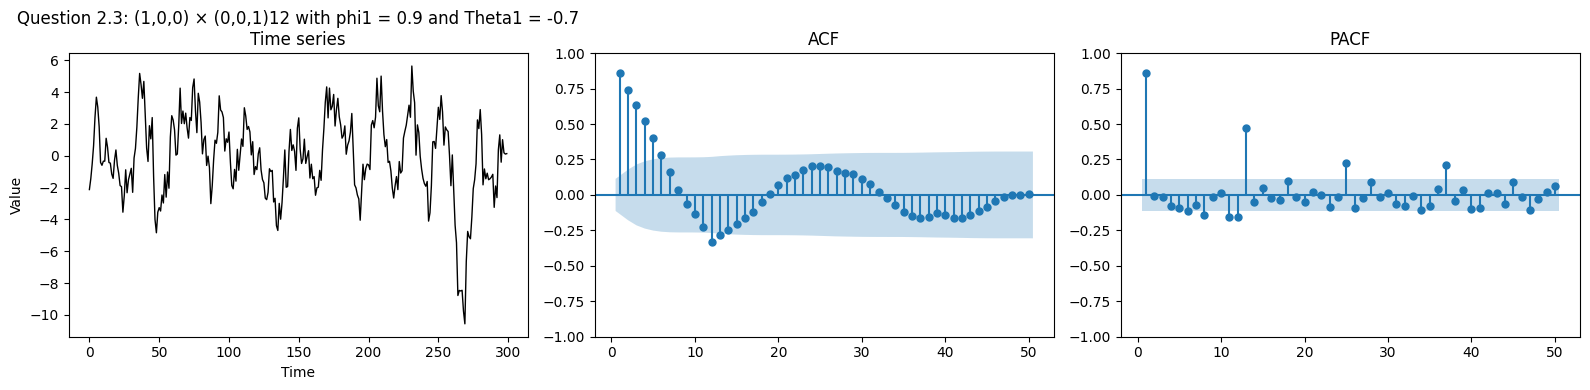

In [5]:
# Question 2.3
series_23, ar_poly_23, ma_poly_23 = simulate_multiplicative_seasonal_arma(
    ar_coefs=[0.9],
    ma_coefs=[],
    sar_coefs=[],
    sma_coefs=[-0.7],
    season_length=12,
    n=300,
    seed=123,
)

print("AR polynomial coefficients:", ar_poly_23)
print("MA polynomial coefficients:", ma_poly_23)

plot_series_acf_pacf(series_23, "Question 2.3: (1,0,0) × (0,0,1)12 with phi1 = 0.9 and Theta1 = -0.7")

# Exam summary (recipe):
# This is a mixed model: the AR part gives slow decay, and the seasonal MA part
# adds extra structure near the seasonal lags.


### Comment on 2.3

The AR(1) part creates strong persistence, so the ACF falls slowly.
The seasonal MA part adds extra structure near lag 12.
This is a mixed model, so the patterns are not as clean as in pure AR or pure MA cases.


## 2.4 Model $(1,0,0) \times (1,0,0)_{12}$ with $\phi_1 = -0.6$ and $\Phi_1 = -0.8$

This is an AR model with:
- one non-seasonal AR term,
- one seasonal AR term.

Expected pattern:
- ACF tails off,
- seasonal structure at multiples of 12,
- some oscillation because both AR coefficients are negative.


AR polynomial coefficients: [1.   0.6  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.8  0.48]
MA polynomial coefficients: [1.]


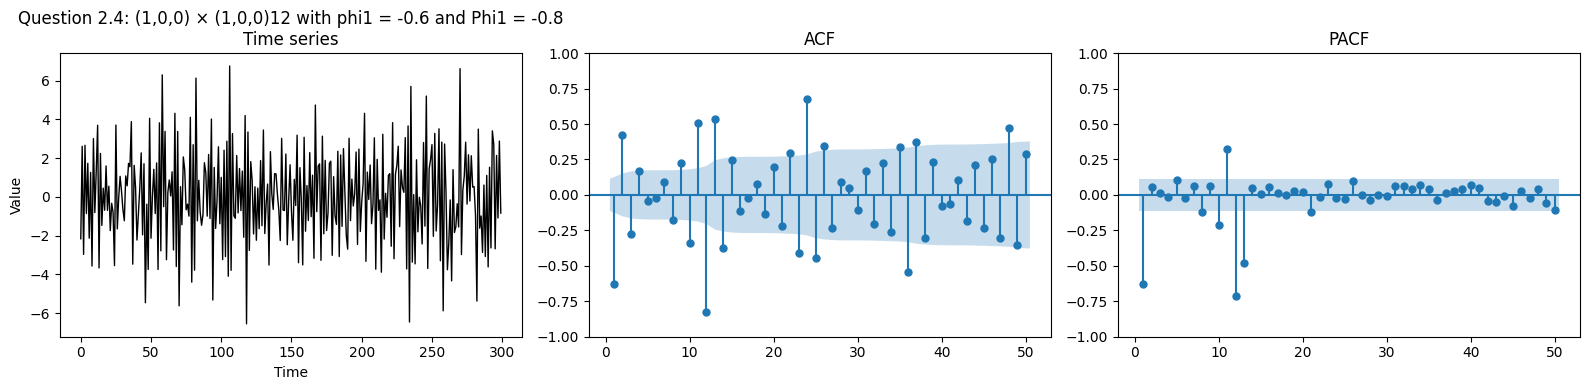

In [6]:
# Question 2.4
series_24, ar_poly_24, ma_poly_24 = simulate_multiplicative_seasonal_arma(
    ar_coefs=[-0.6],
    ma_coefs=[],
    sar_coefs=[-0.8],
    sma_coefs=[],
    season_length=12,
    n=300,
    seed=123,
)

print("AR polynomial coefficients:", ar_poly_24)
print("MA polynomial coefficients:", ma_poly_24)

plot_series_acf_pacf(series_24, "Question 2.4: (1,0,0) × (1,0,0)12 with phi1 = -0.6 and Phi1 = -0.8")

# Exam summary (recipe):
# In AR-type models, the ACF usually tails off. Here we also expect seasonal
# structure because of the seasonal AR term.


### Comment on 2.4

The model shows both short-run and seasonal dependence.
The ACF decays rather than cutting off, which fits an AR-type model, and the seasonal behavior appears at the expected lags.
The PACF helps reveal the direct lag structure more clearly.


## 2.5 Model $(0,0,1) \times (0,0,1)_{12}$ with $\theta_1 = 0.4$ and $\Theta_1 = -0.8$

This is a multiplicative MA model.

Expected pattern:
- the ACF is most important here,
- key lags are around 1, 12, and 13,
- the PACF should taper more gradually.


AR polynomial coefficients: [1.]
MA polynomial coefficients: [ 1.    0.4   0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 -0.8  -0.32]


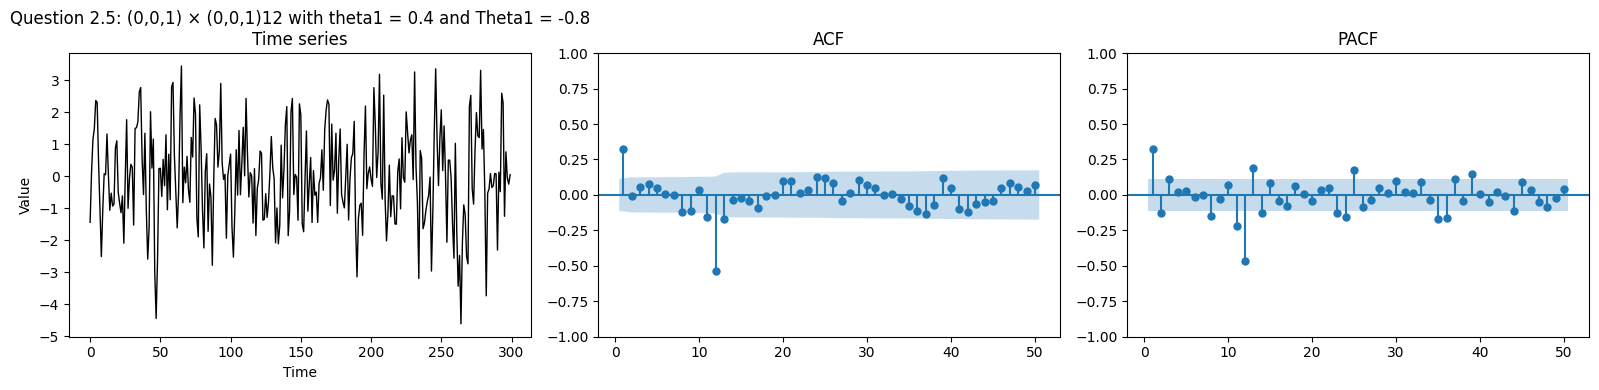

In [7]:
# Question 2.5
series_25, ar_poly_25, ma_poly_25 = simulate_multiplicative_seasonal_arma(
    ar_coefs=[],
    ma_coefs=[0.4],
    sar_coefs=[],
    sma_coefs=[-0.8],
    season_length=12,
    n=300,
    seed=123,
)

print("AR polynomial coefficients:", ar_poly_25)
print("MA polynomial coefficients:", ma_poly_25)

plot_series_acf_pacf(series_25, "Question 2.5: (0,0,1) × (0,0,1)12 with theta1 = 0.4 and Theta1 = -0.8")

# Exam summary (recipe):
# For MA models, the ACF is usually the first thing to read. In multiplicative
# MA models, watch for the extra interaction lag as well.


### Comment on 2.5

This behaves like a mixed MA model.
The ACF is the main guide and should show the short-lag and seasonal-lag effects more directly than the PACF.
The extra lag 13 appears because of the multiplicative structure.


## 2.6 Model $(0,0,1) \times (1,0,0)_{12}$ with $\theta_1 = -0.4$ and $\Phi_1 = 0.7$

This model combines:
- a short-run MA(1),
- and a seasonal AR(1).

Expected pattern:
- local effect at small lags,
- seasonal persistence at $12,24,36,\dots$.


AR polynomial coefficients: [ 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  -0.7]
MA polynomial coefficients: [ 1.  -0.4]


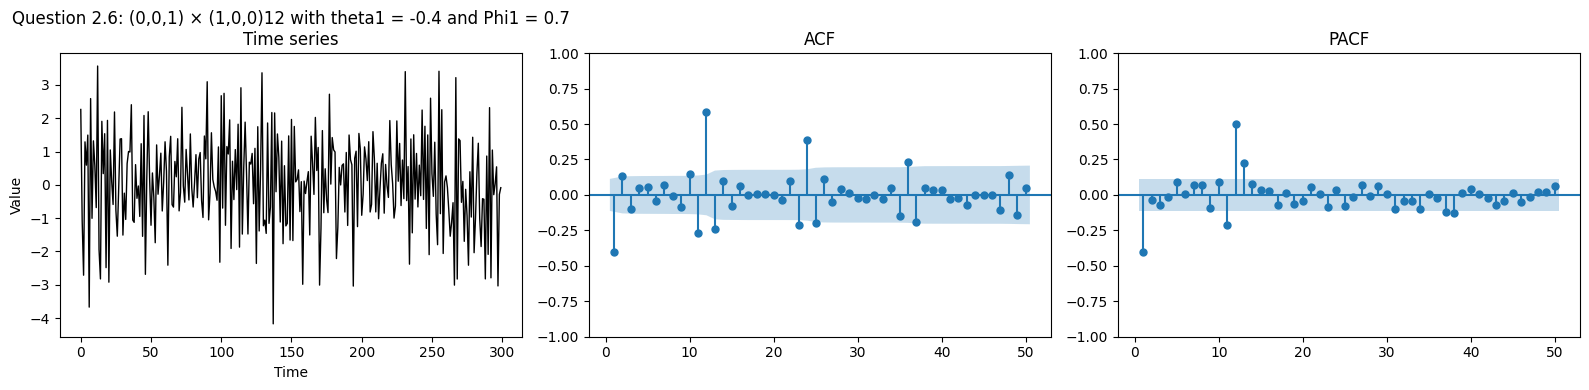

In [8]:
# Question 2.6
series_26, ar_poly_26, ma_poly_26 = simulate_multiplicative_seasonal_arma(
    ar_coefs=[],
    ma_coefs=[-0.4],
    sar_coefs=[0.7],
    sma_coefs=[],
    season_length=12,
    n=300,
    seed=123,
)

print("AR polynomial coefficients:", ar_poly_26)
print("MA polynomial coefficients:", ma_poly_26)

plot_series_acf_pacf(series_26, "Question 2.6: (0,0,1) × (1,0,0)12 with theta1 = -0.4 and Phi1 = 0.7")

# Exam summary (recipe):
# Read the short lags for the MA part and the seasonal lags for the seasonal AR part.
# Mixed models usually need both views.


### Comment on 2.6

The short-lag part is mainly driven by the MA term, while the repeated seasonal structure comes from the seasonal AR term.
So the plot should be read in two layers: short-run behavior first, then seasonal behavior.


## 2.7 Summary of observations

A quick rule of thumb:

- **AR:** ACF tails off, PACF cuts off.
- **MA:** ACF cuts off, PACF tails off.
- **Seasonal AR:** strongest structure at seasonal lags.
- **Seasonal MA:** seasonal spikes/cutoff at seasonal lags.

Mixed models combine these patterns, so they usually look less clean.


# 3. Identifying ARMA models from ACF and PACF plots

In this part, we use the provided figure and identify the most likely model for each process.

The usual rule is:
- look at the ACF first,
- then use the PACF to confirm the guess.


## Provided identification figure

The next cell simply displays the figure used for Question 3.


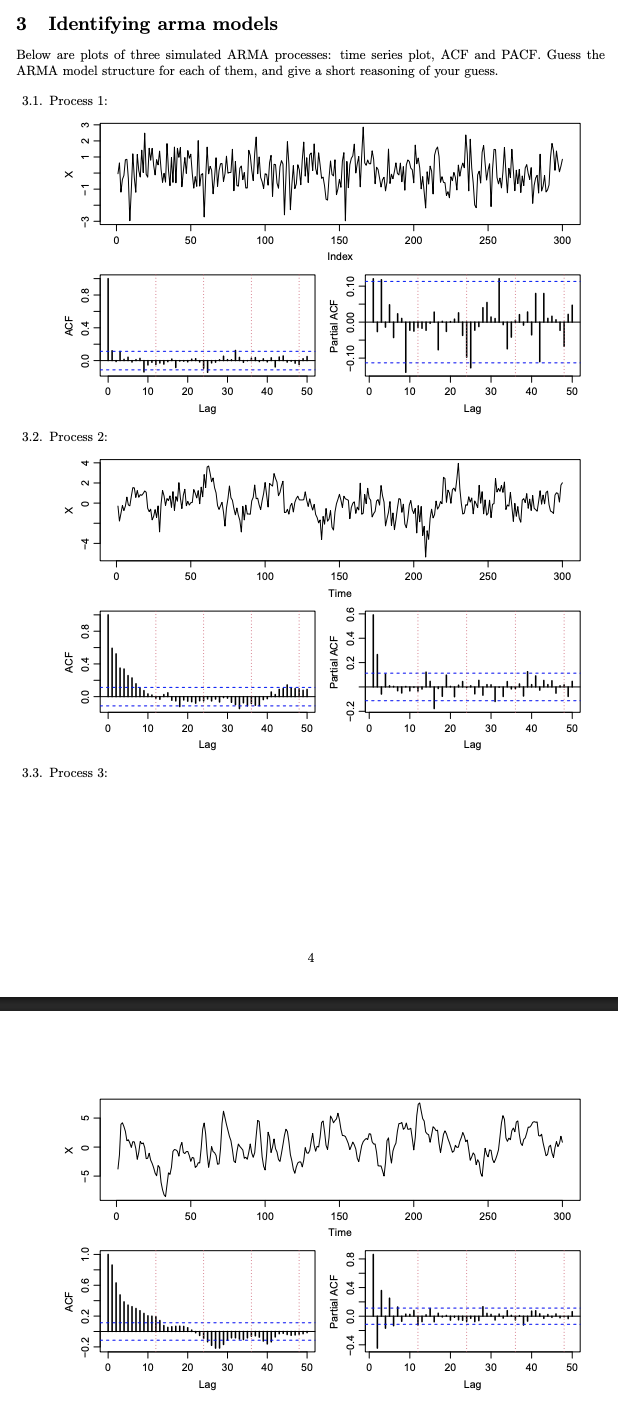

In [9]:
# Figure used for Question 3
figure_path = "assignment2_identification_plots.png"

# Tiny safety note: this path should point to the image saved next to the notebook
display(Image(filename=figure_path))

# Exam summary (recipe):
# Compare ACF and PACF together: cutoff vs tail-off is the main clue.


## Model guesses and short reasoning

### Process 1
This looks like **white noise / ARMA(0,0)**.  
The series has no clear persistence, and both ACF and PACF stay close to zero apart from random small spikes.

### Process 2
This looks like **AR(2)**.  
The ACF tails off, while the PACF has two clearly important early lags.

### Process 3
This looks like a **low-order mixed ARMA model**, for example ARMA(1,1).  
Both ACF and PACF fade gradually instead of showing a clean cutoff.


# Final conclusion

This notebook covers all parts of Assignment 2 in Python only:

- AR(2) stability and theoretical ACF,
- seasonal process simulations and interpretation,
- ARMA identification from ACF/PACF.

